In [1]:
#!pip install intake-esm
#!pip install gcsfs==2023.6.0
#!pip install xmip
!pip install "numpy<1.27"

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from xmip.preprocessing import combined_preprocessing
from xmip.utils import google_cmip_col
from xmip.postprocessing import match_metrics
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import numpy as np

In [3]:
col = google_cmip_col()
col

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,61


In [4]:
col.df['source_id'].unique()

<ArrowExtensionArray>
[      'CMCC-CM2-HR4',      'EC-Earth3P-HR',    'HadGEM3-GC31-MM',
    'HadGEM3-GC31-HM',    'HadGEM3-GC31-LM',         'EC-Earth3P',
       'ECMWF-IFS-HR',       'ECMWF-IFS-LR',    'HadGEM3-GC31-LL',
      'CMCC-CM2-VHR4',           'GFDL-CM4',           'GFDL-AM4',
       'IPSL-CM6A-LR',           'E3SM-1-0',         'CNRM-CM6-1',
          'GFDL-ESM4',         'GFDL-ESM2M',       'GFDL-CM4C192',
        'GFDL-OM4p5B',        'GISS-E2-1-G',        'GISS-E2-1-H',
        'CNRM-ESM2-1',        'BCC-CSM2-MR',           'BCC-ESM1',
             'MIROC6',      'AWI-CM-1-1-MR',       'EC-Earth3-LR',
   'IPSL-CM6A-ATM-HR',              'CESM2',        'CESM2-WACCM',
      'CNRM-CM6-1-HR',         'MRI-ESM2-0',        'SAM0-UNICON',
     'GISS-E2-1-G-CC',        'UKESM1-0-LL',          'EC-Earth3',
      'EC-Earth3-Veg',        'FGOALS-f3-L',            'CanESM5',
      'CanESM5-CanOE',          'INM-CM4-8',          'INM-CM5-0',
              'NESM3',    'MPI-ESM-1-2-H

In [5]:
col.df['variable_id'].unique()

<ArrowExtensionArray>
[               'ps',              'rsds',              'rlus',
              'rlds',               'psl',              'hurs',
              'huss',               'hus',              'hfss',
              'rsus',
 ...
        'sidmassdyn',    'siforcecoriolx',    'siforceintstry',
 'ocontemppsmadvect',          'difmxylo',       'msftyrhompa',
       'msftmrhompa',            'phabio',           'co3abio',
          'difmxybo']
Length: 700, dtype: large_string[pyarrow]

In [6]:
pd.set_option('display.max_seq_items', None)

col.df['table_id'].unique()

<ArrowExtensionArray>
[       'Amon',     '6hrPlev',         '3hr',         'day',       'EmonZ',
        'E3hr',   '6hrPlevPt',      'AERmon',       'LImon',       'CFmon',
        'Lmon',          'fx',       'SImon',         'Ofx',        'Omon',
       'EdayZ',        'Emon',       'CFday',      'AERday',        'Eday',
         'Oyr',         'Eyr',        'Oday',       'SIday',     'AERmonZ',
      '6hrLev', 'E1hrClimMon',       'CF3hr',       'AERhr',        'Odec',
       'Oclim',         'Efx',       'Aclim',      'SIclim',      'IfxGre',
     'ImonGre',       'Eclim']
Length: 37, dtype: large_string[pyarrow]

In [7]:
cat  = col.search(variable_id='tas', 
                  table_id = 'Amon', 
                  experiment_id='historical',
                  source_id='GFDL-ESM4')
cat

,unique
activity_id,1
institution_id,1
source_id,1
experiment_id,1
member_id,3
table_id,1
variable_id,1
grid_label,1
zstore,3
dcpp_init_year,1


In [8]:
cat.df['member_id'].unique()

<ArrowExtensionArray>
['r3i1p1f1', 'r2i1p1f1', 'r1i1p1f1']
Length: 3, dtype: large_string[pyarrow]

In [9]:
cat  = col.search(variable_id='tas', 
                  table_id = 'Amon', 
                  experiment_id='historical',
                  grid_label='gn',
                  source_id=['CESM2', 'CanESM5', 'NorESM2-LM'],
                 member_id=['r3i1p1f1', 'r2i1p1f1', 'r1i1p1f1'])
ddict = cat.to_dataset_dict(preprocess=combined_preprocessing, 
                            xarray_open_kwargs={'use_cftime':True}, 
                            storage_options={'token':'anon'})


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="3" value="3"></progress> 100.00% [3/3 00:07&lt;00:00]</div>

/home/danielmw/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeoai23/share/proj failed


In [10]:
list(ddict.keys())

['CMIP.NCAR.CESM2.historical.Amon.gn',
 'CMIP.CCCma.CanESM5.historical.Amon.gn',
 'CMIP.NCC.NorESM2-LM.historical.Amon.gn']

In [11]:
ddict['CMIP.NCAR.CESM2.historical.Amon.gn']

<xarray.Dataset> Size: 1GB
Dimensions:         (member_id: 3, dcpp_init_year: 1, time: 1980, y: 192,
                     x: 288, nbnd: 2)
Coordinates:
  * y               (y) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * x               (x) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time            (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:...
    time_bounds     (time, nbnd) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
    lat_bounds      (y, nbnd, x) float64 885kB dask.array<chunksize=(192, 2, 288), meta=np.ndarray>
    lon_bounds      (x, nbnd, y) float64 885kB dask.array<chunksize=(288, 2, 192), meta=np.ndarray>
  * nbnd            (nbnd) int64 16B 0 1
    lon             (x, y) float64 442kB 360.0 360.0 360.0 ... 358.8 358.8 358.8
    lat             (x, y) float64 442kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * member_id       (member_id) object 24B 'r1i1p1f1' 'r2i1p1f1' 'r3i1p1f1'
  * dcpp_init_year  (dcpp_init_year) object 8B None
Data variables:
    tas             (member_id, dcpp_init_year, time, y, x) float32 1GB dask.array<chunksize=(1, 1, 600, 192, 288), meta=np.ndarray>
Attributes: (12/50)
    Conventions:                      CF-1.7 CMIP-6.2
    activity_id:                      CMIP
    branch_method:                    standard
    branch_time_in_child:             674885.0
    contact:                          cesm_cmip6@ucar.edu
    data_specs_version:               01.00.29
    ...                               ...
    intake_esm_attrs:table_id:        Amon
    intake_esm_attrs:variable_id:     tas
    intake_esm_attrs:grid_label:      gn
    intake_esm_attrs:version:         20190308
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.NCAR.CESM2.historical.Amon.gn

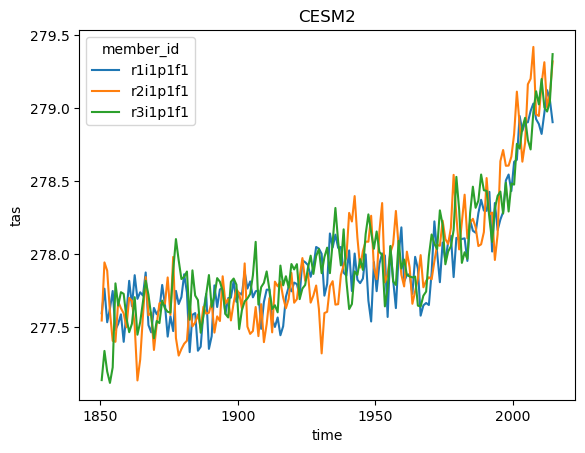

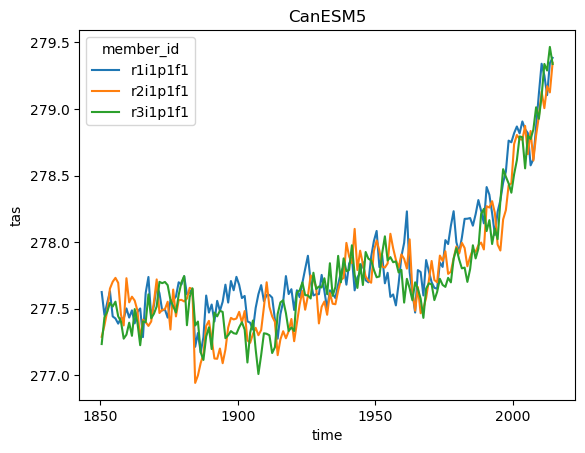

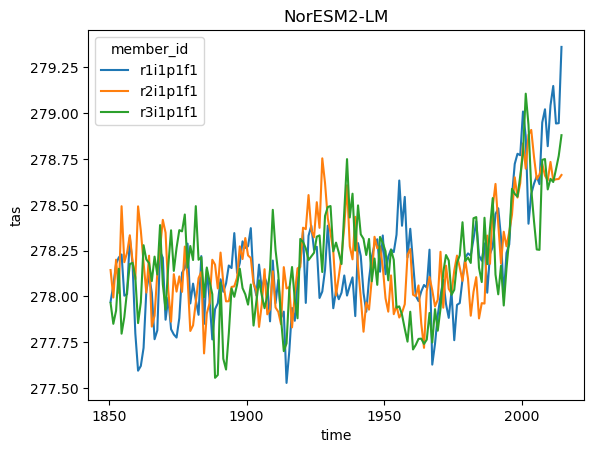

In [12]:
for name, ds in ddict.items(): 
    mean_temp = ds.tas.mean(['x','y']).coarsen(time=12).mean()
    plt.figure()
    mean_temp.plot(hue='member_id')
    plt.title(ds.attrs['source_id'])
    plt.show()



In [13]:
catt  = col.search(variable_id='areacella', 
                  table_id = 'fx', 
                  experiment_id='historical',
                  grid_label='gn',
                  source_id=['CESM2', 'CanESM5', 'NorESM2-LM'],
                 member_id=['r3i1p1f1', 'r2i1p1f1', 'r1i1p1f1'])
ddict_area = catt.to_dataset_dict(preprocess=combined_preprocessing, 
                            xarray_open_kwargs={'use_cftime':True}, 
                            storage_options={'token':'anon'})


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="3" value="3"></progress> 100.00% [3/3 00:03&lt;00:00]</div>

In [14]:
ddict_w_area = match_metrics(ddict, ddict_area, 'areacella')

/home/danielmw/.local/lib/python3.10/site-packages/xmip/postprocessing.py:89: UserWarning: Match attributes ['variant_label'] not found in any of the datasets.         This can happen when several combination functions are used and attributes are removed during merging.         Double check the results.
  warnings.warn(


In [15]:
list(ddict_w_area.keys())


['CMIP.NCAR.CESM2.historical.Amon.gn',
 'CMIP.CCCma.CanESM5.historical.Amon.gn',
 'CMIP.NCC.NorESM2-LM.historical.Amon.gn']

In [16]:
ddict_w_area['CMIP.NCAR.CESM2.historical.Amon.gn']

<xarray.Dataset> Size: 1GB
Dimensions:         (member_id: 3, dcpp_init_year: 1, time: 1980, y: 192,
                     x: 288, nbnd: 2)
Coordinates:
  * y               (y) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * x               (x) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time            (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:...
    time_bounds     (time, nbnd) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
    lat_bounds      (y, nbnd, x) float64 885kB dask.array<chunksize=(192, 2, 288), meta=np.ndarray>
    lon_bounds      (x, nbnd, y) float64 885kB dask.array<chunksize=(288, 2, 192), meta=np.ndarray>
  * nbnd            (nbnd) int64 16B 0 1
    lon             (x, y) float64 442kB 360.0 360.0 360.0 ... 358.8 358.8 358.8
    lat             (x, y) float64 442kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * member_id       (member_id) object 24B 'r1i1p1f1' 'r2i1p1f1' 'r3i1p1f1'
  * dcpp_init_year  (dcpp_init_year) object 8B None
    areacella       (member_id, dcpp_init_year, y, x) float32 664kB dask.array<chunksize=(1, 1, 192, 288), meta=np.ndarray>
Data variables:
    tas             (member_id, dcpp_init_year, time, y, x) float32 1GB dask.array<chunksize=(1, 1, 600, 192, 288), meta=np.ndarray>
Attributes: (12/50)
    Conventions:                      CF-1.7 CMIP-6.2
    activity_id:                      CMIP
    branch_method:                    standard
    branch_time_in_child:             674885.0
    contact:                          cesm_cmip6@ucar.edu
    data_specs_version:               01.00.29
    ...                               ...
    intake_esm_attrs:table_id:        Amon
    intake_esm_attrs:variable_id:     tas
    intake_esm_attrs:grid_label:      gn
    intake_esm_attrs:version:         20190308
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.NCAR.CESM2.historical.Amon.gn

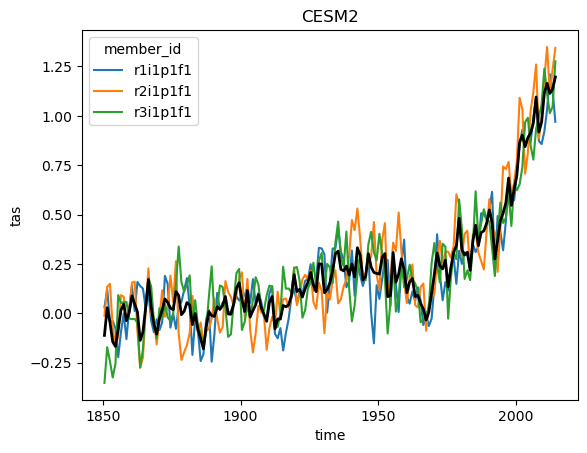

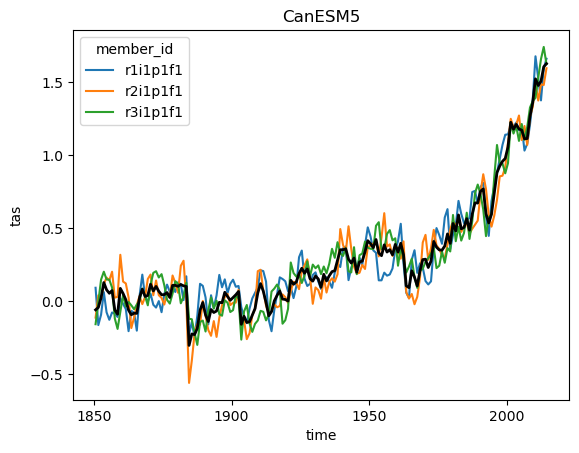

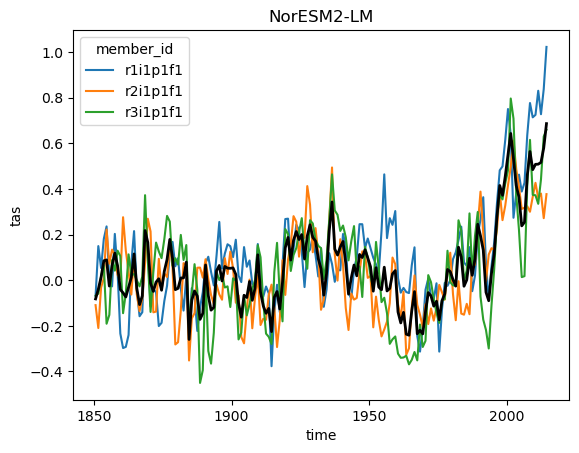

In [17]:
for name, ds in ddict_w_area.items(): 
    weights = ds.areacella
    mean_temp = ds.tas.weighted(weights).mean(['x','y']).coarsen(time=12).mean()
    anomaly = mean_temp - mean_temp.sel(time=slice('1850','1900')).mean('time')
    plt.figure()
    anomaly.plot(hue='member_id')
    anomaly.mean('member_id').plot(color='k',linewidth=2)
    plt.title(ds.attrs['source_id'])
    plt.show()



In [ ]:
import pandas as pd
import numpy as np

# Download GISTEMP v4 Land-Ocean Temperature Index (global mean)
# Anomalies are relative to 1951-1980 baseline
url = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'
gistemp = pd.read_csv(url, skiprows=1, na_values='***')

# Extract annual mean (Jan-Dec column = 'J-D') and the year
gistemp_annual = gistemp[['Year', 'J-D']].dropna()
gistemp_annual = gistemp_annual[gistemp_annual['Year'] <= 2014]  # match historical experiment range
gistemp_annual

Text(0, 0.5, 'GMST anomaly (1951-1980 baseline)')

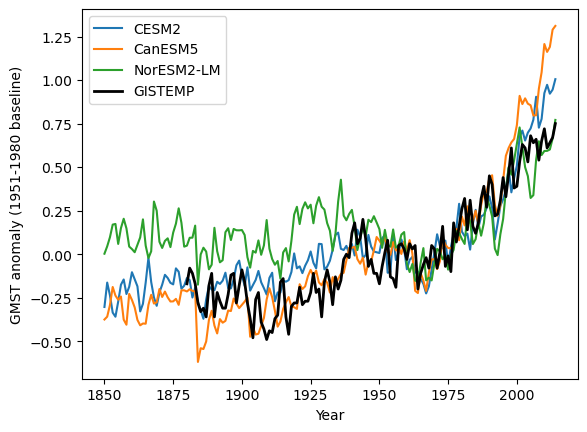

In [24]:
plt.figure()
for name, ds in ddict_w_area.items():
    weights = ds.areacella
    mean_temp_weighted = ds['tas'].weighted(weights).mean(['x','y']).coarsen(time=12).mean()
    anomaly = mean_temp_weighted - mean_temp_weighted.sel(
        time=slice('1951','1980')).mean('time')
    ensemble_mean = anomaly.mean('member_id')
    years = np.array([int(t.year) for t in ensemble_mean.time.values])
    vals = ensemble_mean.values.squeeze()
    plt.plot(years,vals, label=ds.attrs['source_id'])

plt.plot(gistemp_annual['Year'].values, gistemp_annual['J-D'].values, 
         color='k', linewidth=2, label='GISTEMP')
plt.legend()
plt.xlabel('Year')
plt.ylabel('GMST anomaly (1951-1980 baseline)')


Text(0.5, 1.0, 'Global average surface temperature')

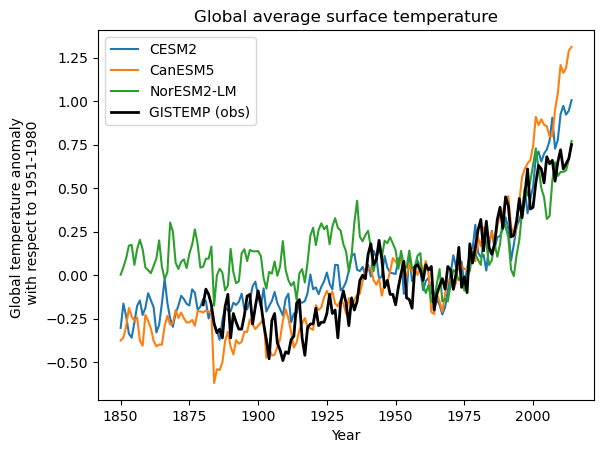

In [20]:
plt.figure()
for name, ds in ddict_w_area.items():
    weights = ds.areacella
    mean_temp_weighted = ds['tas'].weighted(weights).mean(['x', 'y']).coarsen(time=12).mean()
    anomaly = mean_temp_weighted - mean_temp_weighted.sel(time=slice('1951', '1980')).mean('time')
    ensemble_mean = anomaly.mean('member_id')
    # Convert to plain python types — no xarray or cftime touches matplotlib
    years = np.array([int(t.year) for t in ensemble_mean.time.values])
    vals = ensemble_mean.values.squeeze()
    plt.plot(years, vals, label=ds.attrs['source_id'])

plt.plot(gistemp_annual['Year'].values, gistemp_annual['J-D'].values, 
         color='k', linewidth=2, label='GISTEMP (obs)')

plt.legend()
plt.xlabel('Year')
plt.ylabel('Global temperature anomaly \n with respect to 1951-1980')
plt.title('Global average surface temperature')